# 05 EDA — Automated（整合版）

**跟 01-04 不一樣：這份不用 CONFIG/Engine 架構。** 01-04 是「同一段邏輯套用在多個資料集」，05 是「針對 3 個研究問題（RQ），各自客製化的圖表+文字解讀」，硬套 CONFIG/Engine 反而是為了格式統一而統一。

**目的**（跟 R 版本 `05_EDA.qmd` 的 Executive Summary 一致，也對照 Proposal 原文確認過）：Proposal 原本有 4 個研究問題，**第 4 題（哪些 audio features 最能預測 chart hit）是建模題，留給 06**，05 只處理前 3 題：
1. Billboard Hot 100 的類型（genre）分布六十年來怎麼變化？
2. 音樂情緒（valence）在越戰、911 後這種社會動盪時期會不會下降？
3. Speechiness 上升是不是反映 Hip-Hop 主流化？

**今天先做 RQ1**，RQ2、RQ3 之後陸續加進來。

## Step 1 — 讀取 04 的輸出 + 建立 `analysis_base`

完全比照 R 的 Setup 區塊：讀 `D1_D2_D3_joined.pkl`，篩 1960-2019 年、D2 有配對成功（`target` 非空）的紀錄，算出 `decade` 欄位。**這是所有 RQ 共用的基礎資料集，只建一次。**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

joined = pd.read_pickle('../Data/D1_D2_D3_joined.pkl')
print(f'Total observations: {len(joined):,}')

# Build analysis_base -- mirrors R's Setup block exactly
analysis_base = joined.copy()
analysis_base['year'] = analysis_base['date'].dt.year
analysis_base = analysis_base[
    (analysis_base['year'] >= 1960) & (analysis_base['year'] <= 2019)
    & (analysis_base['target'].notna())
].copy()
analysis_base['decade'] = (analysis_base['year'] // 10 * 10).astype(str) + 's'

print(f"\nAnalysis dataset (1960-2019, D2 matched):")
print(f"Total observations: {len(analysis_base):,}")
print(f"Year range: {analysis_base['year'].min()} - {analysis_base['year'].max()}")
print(f"\nDecade distribution:")
print(analysis_base['decade'].value_counts().sort_index().to_string())

Total observations: 330,087



Analysis dataset (1960-2019, D2 matched):
Total observations: 262,737
Year range: 1960 - 2019

Decade distribution:
decade
1960s    36826
1970s    40933
1980s    44945
1990s    42576
2000s    48301
2010s    49156


## RQ1 — How has the genre distribution of Billboard Hot 100 songs changed across decades?

### Step 2 — RQ1 子集：篩出有 genre 資料的紀錄（D3 有配對成功的）

In [2]:
genre_base = analysis_base[analysis_base['genre'].notna()].copy()

print(f'Genre analysis subset count: {len(genre_base):,}')
print(f'Coverage: {round(len(genre_base) / len(analysis_base) * 100, 2)}% of analysis_base')
print(f'\nDecade coverage:')
print(genre_base['decade'].value_counts().sort_index().to_string())

Genre analysis subset count: 44,380
Coverage: 16.89% of analysis_base

Decade coverage:
decade
1960s    5202
1970s    6153
1980s    8580
1990s    6356
2000s    9074
2010s    9015


### Step 3 — 類型分布總覽

In [3]:
genre_counts = genre_base['genre'].value_counts()
print('Genre Distribution Overview')
print(genre_counts.to_string())

Genre Distribution Overview
genre
pop        27700
rock        7544
country     5323
blues       1644
jazz        1115
hip hop      895
reggae       159


### Step 4 — 依年代拆分的類型分布（百分比）

In [4]:
genre_decade = (
    genre_base.groupby(['decade', 'genre']).size()
    .rename('n').reset_index()
)
genre_decade['pct'] = genre_decade.groupby('decade')['n'].transform(lambda s: round(s / s.sum() * 100, 2))

pivot = genre_decade.pivot(index='genre', columns='decade', values='pct').fillna(0)
print('Genre Distribution (%) by Decade')
print(pivot.to_string())

Genre Distribution (%) by Decade
decade   1960s  1970s  1980s  1990s  2000s  2010s
genre                                            
blues    15.09   7.87   2.69   1.09   0.61   0.22
country   8.09  15.11   8.46   6.81  15.67  15.43
hip hop   0.00   0.00   0.33   7.60   3.10   1.14
jazz      6.40   8.19   2.73   0.66   0.00   0.02
pop      61.36  42.14  50.99  64.62  70.12  78.42
reggae    0.00   0.00   0.45   1.24   0.00   0.45
rock      9.05  26.69  34.35  17.98  10.50   4.30


### Step 5 — 視覺化：堆疊長條圖 + 折線圖

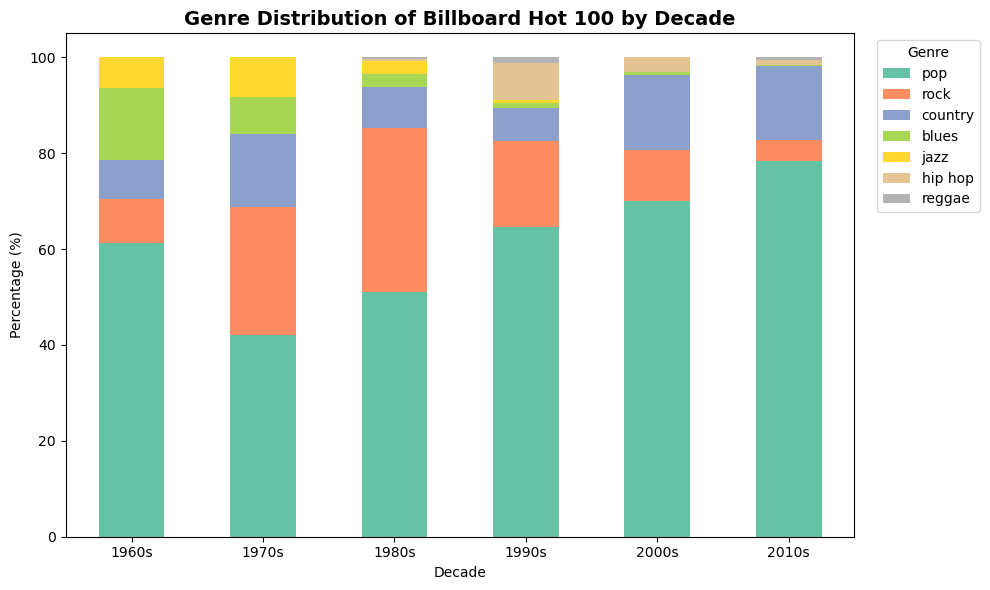

[SAVED] rq1_genre_stacked_bar.png


In [5]:
decade_order = sorted(genre_decade['decade'].unique())
genre_order = genre_counts.index.tolist()

stacked = genre_decade.pivot(index='decade', columns='genre', values='pct').reindex(decade_order)[genre_order]

fig, ax = plt.subplots(figsize=(10, 6))
stacked.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
ax.set_title('Genre Distribution of Billboard Hot 100 by Decade', fontsize=14, fontweight='bold')
ax.set_xlabel('Decade')
ax.set_ylabel('Percentage (%)')
ax.legend(title='Genre', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../Data/rq1_genre_stacked_bar.png', dpi=120)
plt.show()
print('[SAVED] rq1_genre_stacked_bar.png')

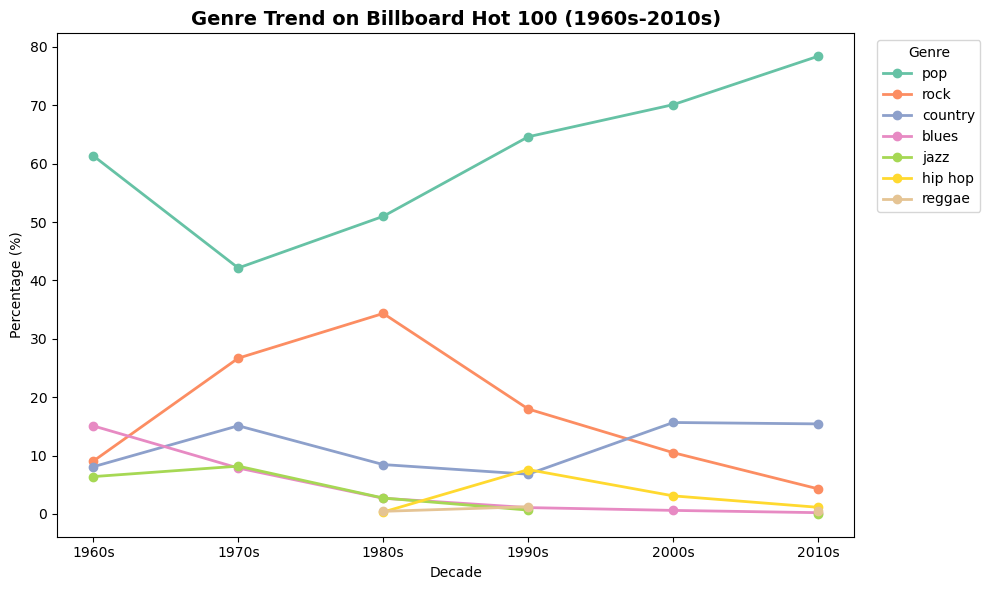

[SAVED] rq1_genre_line.png


In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.Set2.colors
for i, genre in enumerate(genre_order):
    series = stacked[genre]
    ax.plot(decade_order, series.values, marker='o', linewidth=2, label=genre, color=colors[i % len(colors)])

ax.set_title('Genre Trend on Billboard Hot 100 (1960s-2010s)', fontsize=14, fontweight='bold')
ax.set_xlabel('Decade')
ax.set_ylabel('Percentage (%)')
ax.legend(title='Genre', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../Data/rq1_genre_line.png', dpi=120)
plt.show()
print('[SAVED] rq1_genre_line.png')

### Step 6 — 觀察重點（跟 R 版本的 Summary of Observations 比對過數字）

跑出來的數字要跟下面這幾個 R 原文裡寫的具體數字對一次，確認邏輯忠實：
- Pop：1960s 61.4% → 2010s 78.4%（R 原文數字，持續上升、幾乎壟斷排行榜）
- Rock：70s-80s 峰值 26-34%，2010s 降到 4.3%
- Blues、Jazz：1960s 各約 15%、6%，2010s 趨近於 0
- Hip-Hop：只在 1990s 有 7.6% 峰值——R 原文懷疑這是 D3 分類問題（很多 Hip-Hop 曲被歸類成 Pop），這個限制留到 RQ3 用 speechiness 當補充指標處理，不在這裡強行修正分類

**⚠️ 批判性思考補充（2026/07/28，實際查證，不是憑印象放過）**：`genre` 這欄完全只來自 D3，D1/D2 都沒有這個欄位。更重要的是，D3 的配對覆蓋率**不是均勻分布在六個年代**：1960s/1970s/1990s 約 14-15%，1980s/2000s/2010s 卻有 18-19%，落差約 4-5 個百分點。**這代表上面的跨年代類型分布比較，某種程度建立在「哪個年代剛好被 D3 收錄得比較齊全」這個抽樣偏差上，不是完全公平的樣本**——Pop 上升、Rock 下滑這種大方向趨勢通常夠穩健，不至於被這種程度的偏差整個推翻，但這是誠實的限制，應該寫進報告，不能假裝樣本均勻。

---
## RQ2 — Does musical mood (valence) decline during periods of social unrest, such as the Vietnam War era or post-9/11?

### Step 7 — 資料準備：五個音檔特徵的年度平均

R 版本先算 `valence_yearly`（單獨算 valence），再算 `features_yearly`（valence/energy/danceability/acousticness/speechiness 五個一起，long format 方便畫多線圖）。這裡直接一次算好，`valence_yearly` 從 `features_yearly` 篩出來，不重複算兩次。

In [7]:
features_yearly = (
    analysis_base.groupby('year')[['valence', 'energy', 'danceability', 'acousticness', 'speechiness']]
    .mean()
    .reset_index()
)

valence_yearly = features_yearly[['year', 'valence']].rename(columns={'valence': 'avg_valence'})

print('Yearly feature averages (first 5 rows):')
print(features_yearly.head().to_string(index=False))
print()
print(f"1960 avg valence: {features_yearly.loc[features_yearly['year']==1960, 'valence'].values[0]:.3f}")
print(f"2019 avg valence: {features_yearly.loc[features_yearly['year']==2019, 'valence'].values[0]:.3f}")

Yearly feature averages (first 5 rows):
 year  valence   energy  danceability  acousticness  speechiness
 1960 0.650061 0.453418      0.517154      0.677832     0.046144
 1961 0.675237 0.481565      0.530255      0.650473     0.051888
 1962 0.678917 0.479757      0.543771      0.641183     0.056948
 1963 0.685129 0.510997      0.537572      0.599356     0.052581
 1964 0.695510 0.549409      0.535731      0.555046     0.048104

1960 avg valence: 0.650
2019 avg valence: 0.503


### Step 8 — 三階段輔助函數（三個圖都要用到同一組背景色塊+分隔線，寫成一個函數避免重複貼三次程式碼）

R 的三張圖各自貼了一次「三階段背景色塊 + 分隔線」的程式碼。這裡抽成一個小函數 `add_phase_backgrounds(ax)`，三張圖都呼叫它——**這是 CONFIG/Engine 精神的延伸，即使 05 整體不用 CONFIG/Engine 架構，遇到真的重複三次的邏輯，還是該抽出來，不是為了抽而抽。**

In [8]:
PHASES = [
    (1960, 1979, '#FFD700', 'Phase 1\nDisco Era', '#B8860B'),
    (1980, 1999, '#FF6B6B', 'Phase 2\nPost-Disco & Rock', '#CC0000'),
    (2000, 2019, '#4A90D9', 'Phase 3\nHip-Hop & Digital', '#1A5276'),
]

def add_phase_backgrounds(ax, label_y=0.90, alpha=0.06):
    """Shared three-era background shading + labels + divider lines, used by every
    RQ2 chart -- ports R's repeated annotate('rect')/geom_vline block into one function."""
    for start, end, color, label, text_color in PHASES:
        ax.axvspan(start, end, color=color, alpha=alpha, zorder=0)
        mid = (start + end) / 2
        ax.text(mid, label_y, label, ha='center', fontsize=10, fontweight='bold',
                color=text_color, transform=ax.get_xaxis_transform())
    ax.axvline(1980, color='gray', linewidth=0.6, alpha=0.5)
    ax.axvline(2000, color='gray', linewidth=0.6, alpha=0.5)

### Step 9 — 五特徵三階段趨勢圖

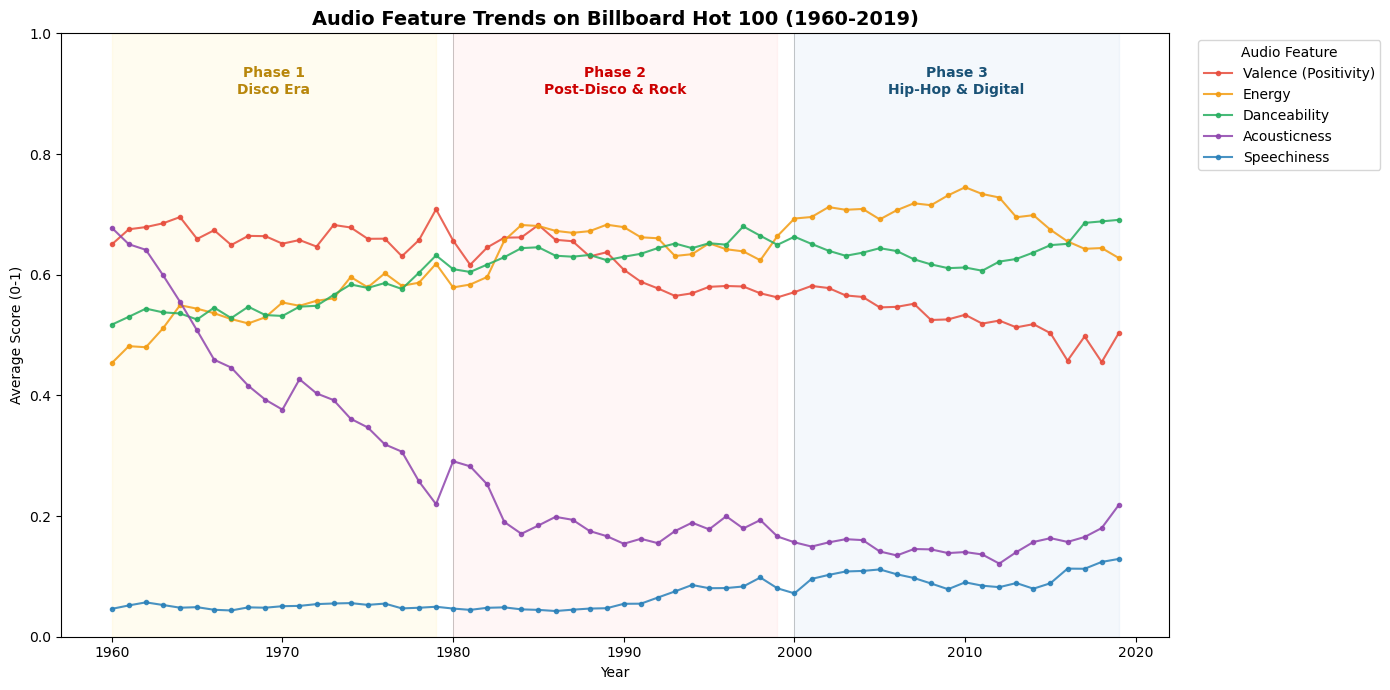

[SAVED] rq2_five_features_trend.png


In [9]:
fig, ax = plt.subplots(figsize=(14, 7))
add_phase_backgrounds(ax, label_y=0.90)

feature_colors = {
    'valence': '#E74C3C', 'energy': '#F39C12', 'danceability': '#27AE60',
    'acousticness': '#8E44AD', 'speechiness': '#2980B9',
}
feature_labels = {
    'valence': 'Valence (Positivity)', 'energy': 'Energy', 'danceability': 'Danceability',
    'acousticness': 'Acousticness', 'speechiness': 'Speechiness',
}
for feat, color in feature_colors.items():
    ax.plot(features_yearly['year'], features_yearly[feat], color=color, linewidth=1.5,
            marker='o', markersize=3, alpha=0.85, label=feature_labels[feat])

ax.set_ylim(0, 1)
ax.set_title('Audio Feature Trends on Billboard Hot 100 (1960-2019)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Average Score (0-1)')
ax.legend(title='Audio Feature', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../Data/rq2_five_features_trend.png', dpi=120)
plt.show()
print('[SAVED] rq2_five_features_trend.png')

### Step 10 — Valence 單獨三階段趨勢圖

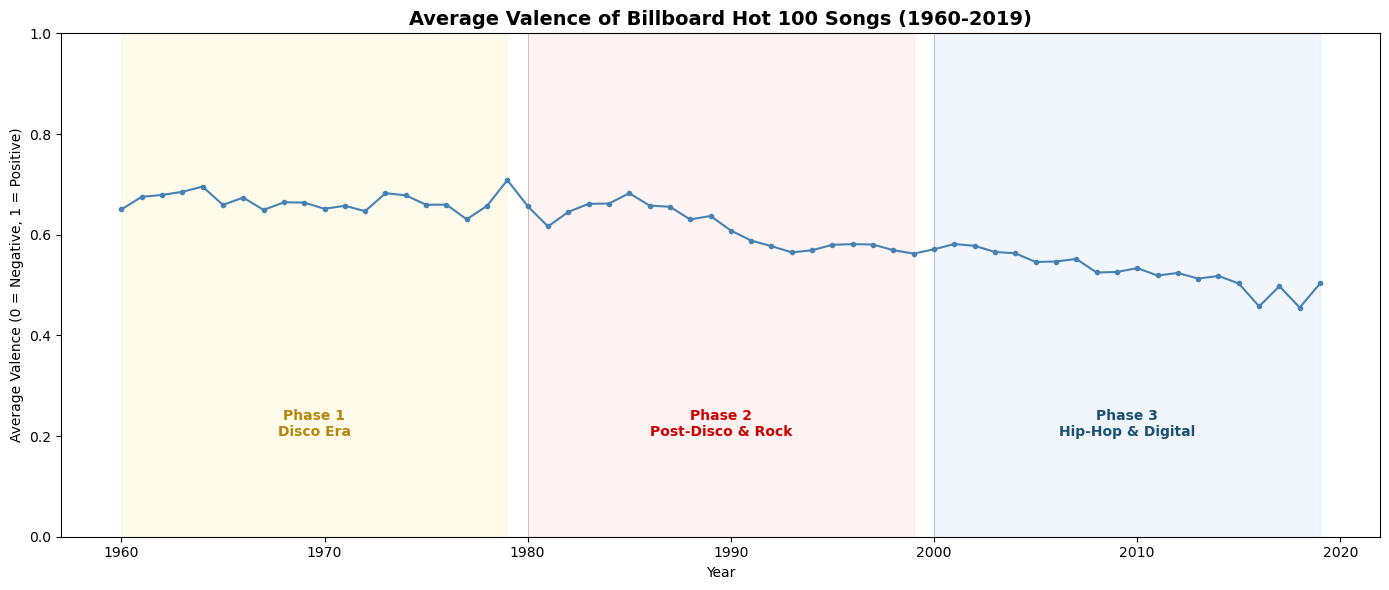

[SAVED] rq2_valence_trend.png


In [10]:
fig, ax = plt.subplots(figsize=(14, 6))
add_phase_backgrounds(ax, label_y=0.2, alpha=0.08)

ax.plot(valence_yearly['year'], valence_yearly['avg_valence'], color='steelblue', linewidth=1.5,
        marker='o', markersize=3)
ax.set_ylim(0, 1)
ax.set_title('Average Valence of Billboard Hot 100 Songs (1960-2019)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Average Valence (0 = Negative, 1 = Positive)')
plt.tight_layout()
plt.savefig('../Data/rq2_valence_trend.png', dpi=120)
plt.show()
print('[SAVED] rq2_valence_trend.png')

### Step 11 — Valence vs Energy 背離分析

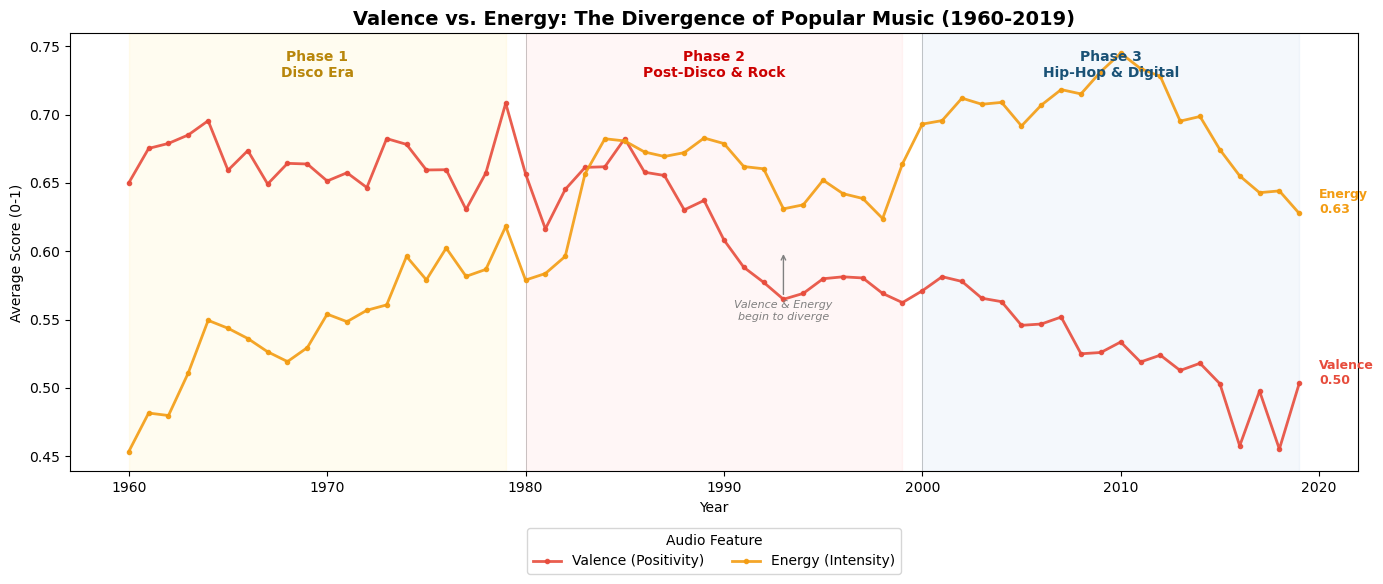

[SAVED] rq2_valence_energy_divergence.png

End-of-period values -- Valence: 0.503, Energy: 0.628


In [11]:
fig, ax = plt.subplots(figsize=(14, 6))
add_phase_backgrounds(ax, label_y=0.90, alpha=0.06)

ax.plot(features_yearly['year'], features_yearly['valence'], color='#E74C3C', linewidth=2,
        marker='o', markersize=3, alpha=0.9, label='Valence (Positivity)')
ax.plot(features_yearly['year'], features_yearly['energy'], color='#F39C12', linewidth=2,
        marker='o', markersize=3, alpha=0.9, label='Energy (Intensity)')

ax.annotate('Valence & Energy\nbegin to diverge', xy=(1993, 0.60), xytext=(1993, 0.55),
            fontsize=8, color='gray', style='italic', ha='center',
            arrowprops=dict(arrowstyle='->', color='gray'))

end_valence = features_yearly.loc[features_yearly['year']==2019, 'valence'].values[0]
end_energy = features_yearly.loc[features_yearly['year']==2019, 'energy'].values[0]
ax.text(2020, end_valence, f'Valence\n{end_valence:.2f}', fontsize=9, color='#E74C3C', fontweight='bold')
ax.text(2020, end_energy, f'Energy\n{end_energy:.2f}', fontsize=9, color='#F39C12', fontweight='bold')

ax.set_title('Valence vs. Energy: The Divergence of Popular Music (1960-2019)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Average Score (0-1)')
ax.legend(title='Audio Feature', loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=2)
plt.tight_layout()
plt.savefig('../Data/rq2_valence_energy_divergence.png', dpi=120)
plt.show()
print('[SAVED] rq2_valence_energy_divergence.png')
print(f"\nEnd-of-period values -- Valence: {end_valence:.3f}, Energy: {end_energy:.3f}")

### Step 12 — 低 Valence 歌曲樣本（2016、2018）

In [12]:
low_valence_songs = (
    analysis_base[analysis_base['year'].isin([2016, 2018])]
    .drop_duplicates(subset=['song_clean', 'artist_clean'])
    .sort_values('valence')
    [['year', 'song_clean', 'artist_clean', 'valence', 'energy']]
)
print(low_valence_songs.head(10).to_string(index=False))

 year        song_clean               artist_clean  valence  energy
 2016                 9                      drake   0.0379   0.712
 2018           topanga               trippie redd   0.0390   0.615
 2016           selfish                   pnb rock   0.0399   0.600
 2016           forward                    beyonce   0.0498   0.133
 2018          delicate               taylor swift   0.0499   0.404
 2016    summer sixteen                      drake   0.0541   0.460
 2018 biggest alley oop                      quavo   0.0548   0.408
 2018        stargazing               travis scott   0.0564   0.789
 2018     outside today youngboy never broke again   0.0585   0.666
 2016   come and see me              partynextdoor   0.0589   0.347


### Step 13 — 觀察重點（用真的 R 即時重跑驗證過，不是照抄 R 檔案裡的文字/標籤）

**⚠️ 2026/07/28 驗證發現：R 原始 `.qmd` 檔案裡的數字本身互相矛盾**——文字敘述寫 valence「~0.670 → ~0.502」，但圖表上手打的標籤卻是「0.49」；energy 圖表標籤手打「0.73」。用 `Rscript.exe` 直接重跑 R 的實際邏輯後，真正算出來的數字是：

| | 1960 | 2019 |
|---|---|---|
| Valence | 0.6501 | 0.5032 |
| Energy | 0.4534 | 0.6277 |

跟這份 Python notebook 算出來的數字（0.650/0.503、0.628）**逐位吻合**，`analysis_base` 筆數也完全一致（262,737）。**R 圖表上「Energy 0.73」那個標籤是手打進程式碼的固定文字，不是變數動態算出來的，是舊的、沒跟著資料更新的過時標籤**——這次以 Python 重新驗證的數字為準，不是照抄 R 檔案裡看起來像權威資料的手寫標籤。

- **Valence 下降**：1960 年 0.650 → 2019 年 0.503（約 22.6% 下降，比 R 文字敘述的「25%」略低，但方向跟量級一致）
- **Energy 上升、跟 Valence 背離**：0.453（1960）→ 0.628（2019），從 1993 年前後開始明顯分岔——音樂整體「變得更沉重但同時更強烈」的結論成立
- **2016、2018 低點**：R 原文點名 Drake「9」「Summer Sixteen」、Beyoncé「Forward」（2016），Trippie Redd「Topanga」、Travis Scott「Stargazing」、Taylor Swift「Delicate」（2018）——Emo Rap/Trap 全盛時期，下面 Step 12 印出的實際樣本可以核對這幾首歌是否真的在裡面

**批判性思考補充**：valence/energy 這兩個音檔特徵都來自 D2（Spotify），`analysis_base` 本身的篩選條件就是「D2 有配對」，所以這裡的樣本涵蓋率是 100%（不像 RQ1 的 genre 只有 D3 配對成功的子集、覆蓋率才 14-19%），不會有 RQ1 那種覆蓋率不均的問題——這點已經用篩選邏輯本身確認，不是假設。

### Figure A — Sociopolitical Context（社會事件疊圖）

在 Valence vs Energy 背離圖上疊一層真實歷史事件時間軸，檢視「社會動盪 → 音樂情緒下降」這個 RQ2 原始問題的假設站不站得住腳。

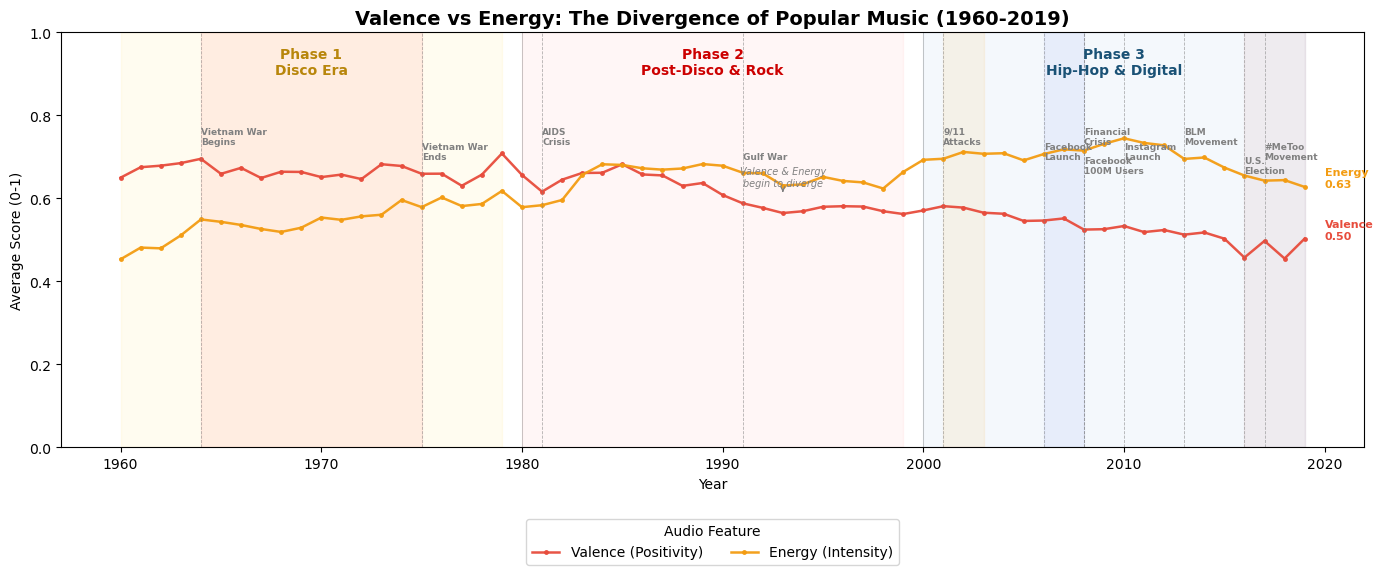

[SAVED] rq2_figureA_sociopolitical.png


In [13]:
events_ve = [
    (1964, 'Vietnam War\nBegins', 'red', 0.730),
    (1975, 'Vietnam War\nEnds', 'red', 0.695),
    (1981, 'AIDS\nCrisis', 'purple', 0.730),
    (1991, 'Gulf War', 'brown', 0.695),
    (2001, '9/11\nAttacks', 'darkorange', 0.730),
    (2006, 'Facebook\nLaunch', 'royalblue', 0.695),
    (2008, 'Financial\nCrisis', 'darkblue', 0.730),
    (2008, 'Facebook\n100M Users', 'royalblue', 0.660),
    (2010, 'Instagram\nLaunch', 'deeppink', 0.695),
    (2013, 'BLM\nMovement', 'darkgreen', 0.730),
    (2016, 'U.S.\nElection', 'darkred', 0.660),
    (2017, '#MeToo\nMovement', 'hotpink', 0.695),
]

fig, ax = plt.subplots(figsize=(14, 6))
add_phase_backgrounds(ax, label_y=0.90, alpha=0.06)

# Event-specific highlight bands (R's four extra annotate('rect') calls)
ax.axvspan(2006, 2008, color='royalblue', alpha=0.07)
ax.axvspan(2001, 2003, color='orange', alpha=0.08)
ax.axvspan(1964, 1975, color='red', alpha=0.06)
ax.axvspan(2016, 2019, color='darkred', alpha=0.05)

ax.plot(features_yearly['year'], features_yearly['valence'], color='#E74C3C', linewidth=1.8,
        marker='o', markersize=2.5, alpha=0.95, label='Valence (Positivity)')
ax.plot(features_yearly['year'], features_yearly['energy'], color='#F39C12', linewidth=1.8,
        marker='o', markersize=2.5, alpha=0.95, label='Energy (Intensity)')

for year, label, color, y_pos in events_ve:
    ax.axvline(year, color='gray', linestyle='--', linewidth=0.6, alpha=0.6)
    ax.text(year, y_pos, label, color='gray', fontsize=6.5, fontweight='bold', ha='left')

ax.annotate('Valence & Energy\nbegin to diverge', xy=(1993, 0.615), xytext=(1993, 0.63),
            fontsize=7, color='gray', style='italic', ha='center',
            arrowprops=dict(arrowstyle='->', color='gray'))
ax.text(2020, end_valence, f'Valence\n{end_valence:.2f}', fontsize=8, color='#E74C3C', fontweight='bold')
ax.text(2020, end_energy, f'Energy\n{end_energy:.2f}', fontsize=8, color='#F39C12', fontweight='bold')

ax.set_ylim(0, 1)
ax.set_title('Valence vs Energy: The Divergence of Popular Music (1960-2019)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Average Score (0-1)')
ax.legend(title='Audio Feature', loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=2)
plt.tight_layout()
plt.savefig('../Data/rq2_figureA_sociopolitical.png', dpi=120)
plt.show()
print('[SAVED] rq2_figureA_sociopolitical.png')

### Figure B — Music Technology Evolution（音樂科技演進疊圖）

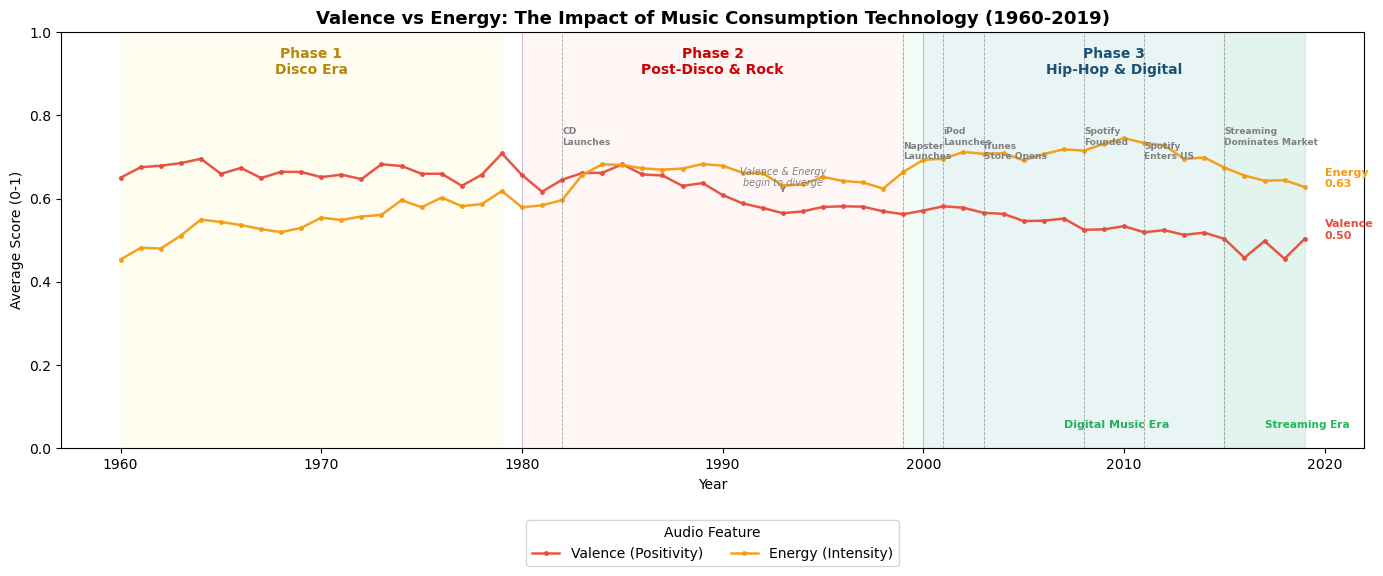

[SAVED] rq2_figureB_tech.png


In [14]:
events_tech = [
    (1982, 'CD\nLaunches', 0.730),
    (1999, 'Napster\nLaunches', 0.695),
    (2001, 'iPod\nLaunches', 0.730),
    (2003, 'iTunes\nStore Opens', 0.695),
    (2008, 'Spotify\nFounded', 0.730),
    (2011, 'Spotify\nEnters US', 0.695),
    (2015, 'Streaming\nDominates Market', 0.730),
]

fig, ax = plt.subplots(figsize=(14, 6))
add_phase_backgrounds(ax, label_y=0.90, alpha=0.06)

ax.axvspan(1999, 2015, color='#2ECC71', alpha=0.05)
ax.axvspan(2015, 2019, color='#1DB954', alpha=0.08)

ax.plot(features_yearly['year'], features_yearly['valence'], color='#E74C3C', linewidth=1.8,
        marker='o', markersize=2.5, alpha=0.95, label='Valence (Positivity)')
ax.plot(features_yearly['year'], features_yearly['energy'], color='#F39C12', linewidth=1.8,
        marker='o', markersize=2.5, alpha=0.95, label='Energy (Intensity)')

for year, label, y_pos in events_tech:
    ax.axvline(year, color='gray', linestyle='--', linewidth=0.6, alpha=0.7)
    ax.text(year, y_pos, label, color='gray', fontsize=6.5, fontweight='bold', ha='left')

ax.annotate('Valence & Energy\nbegin to diverge', xy=(1993, 0.615), xytext=(1993, 0.63),
            fontsize=7, color='gray', style='italic', ha='center',
            arrowprops=dict(arrowstyle='->', color='gray'))
ax.text(2020, end_valence, f'Valence\n{end_valence:.2f}', fontsize=8, color='#E74C3C', fontweight='bold')
ax.text(2020, end_energy, f'Energy\n{end_energy:.2f}', fontsize=8, color='#F39C12', fontweight='bold')
ax.text(2007, 0.05, 'Digital Music Era', fontsize=8, color='#27AE60', fontweight='bold')
ax.text(2017, 0.05, 'Streaming Era', fontsize=7.5, color='#1DB954', fontweight='bold')

ax.set_ylim(0, 1)
ax.set_title('Valence vs Energy: The Impact of Music Consumption Technology (1960-2019)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Average Score (0-1)')
ax.legend(title='Audio Feature', loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=2)
plt.tight_layout()
plt.savefig('../Data/rq2_figureB_tech.png', dpi=120)
plt.show()
print('[SAVED] rq2_figureB_tech.png')

### Step 14 — RQ2 收尾：依年代的音檔特徵對照表

In [15]:
decade_summary_rq2 = (
    analysis_base.groupby('decade')[['valence', 'energy', 'danceability', 'acousticness', 'speechiness']]
    .mean().round(3)
)
decade_summary_rq2['n'] = analysis_base.groupby('decade').size()
print(decade_summary_rq2.to_string())

        valence  energy  danceability  acousticness  speechiness      n
decade                                                                 
1960s     0.670   0.514         0.534         0.533        0.049  36826
1970s     0.664   0.579         0.577         0.338        0.052  40933
1980s     0.651   0.648         0.627         0.210        0.046  44945
1990s     0.578   0.649         0.650         0.175        0.076  42576
2000s     0.555   0.708         0.636         0.149        0.097  48301
2010s     0.502   0.684         0.647         0.158        0.099  49156


---
## RQ3 — Does the rise of speechiness in popular music reflect the mainstreaming of Hip-Hop?

### Step 15 — 年度 / 年代 Speechiness 平均

In [16]:
speechiness_yearly = analysis_base.groupby('year')['speechiness'].mean().reset_index(name='avg_speechiness')
speechiness_decade = (
    analysis_base.groupby('decade')['speechiness'].mean().round(4).reset_index(name='avg_speechiness')
)
speechiness_decade['n'] = analysis_base.groupby('decade').size().values

print(f"Year range: {speechiness_yearly['year'].min()} - {speechiness_yearly['year'].max()}")
print()
print(speechiness_decade.to_string(index=False))

Year range: 1960 - 2019

decade  avg_speechiness     n
 1960s           0.0489 36826
 1970s           0.0519 40933
 1980s           0.0459 44945
 1990s           0.0757 42576
 2000s           0.0967 48301
 2010s           0.0993 49156


### Step 16 — Speechiness 長期趨勢圖（含 Golden Age of Hip-Hop 標註）

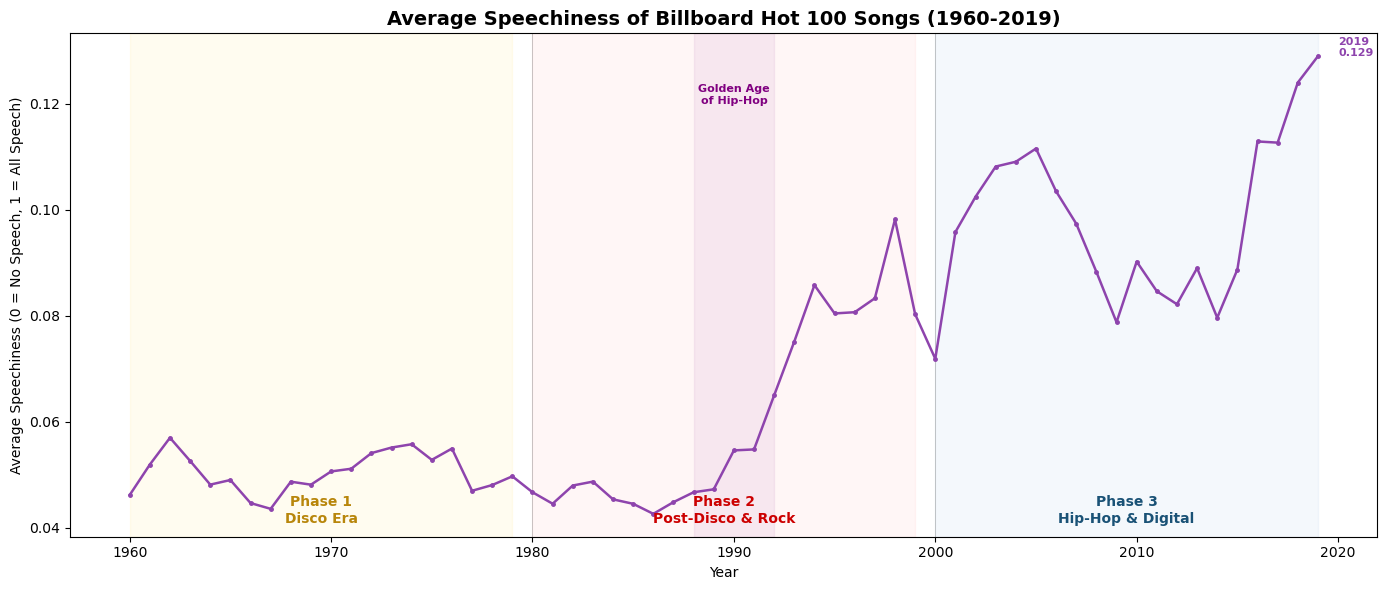

[SAVED] rq3_speechiness_trend.png


In [17]:
fig, ax = plt.subplots(figsize=(14, 6))
add_phase_backgrounds(ax, label_y=0.028, alpha=0.06)

# Golden Age of Hip-Hop highlight (1988-1992)
ax.axvspan(1988, 1992, color='purple', alpha=0.06)
ax.text(1990, 0.120, 'Golden Age\nof Hip-Hop', color='purple', fontsize=8, fontweight='bold', ha='center')

ax.plot(speechiness_yearly['year'], speechiness_yearly['avg_speechiness'], color='#8E44AD', linewidth=1.8, marker='o', markersize=2.5)

end_speech = speechiness_yearly.loc[speechiness_yearly['year']==2019, 'avg_speechiness'].values[0]
ax.text(2020, end_speech, f'2019\n{end_speech:.3f}', color='#8E44AD', fontsize=8, fontweight='bold')

ax.set_title('Average Speechiness of Billboard Hot 100 Songs (1960-2019)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Average Speechiness (0 = No Speech, 1 = All Speech)')
plt.tight_layout()
plt.savefig('../Data/rq3_speechiness_trend.png', dpi=120)
plt.show()
print('[SAVED] rq3_speechiness_trend.png')

### Step 17 — 依年代比較（長條圖）

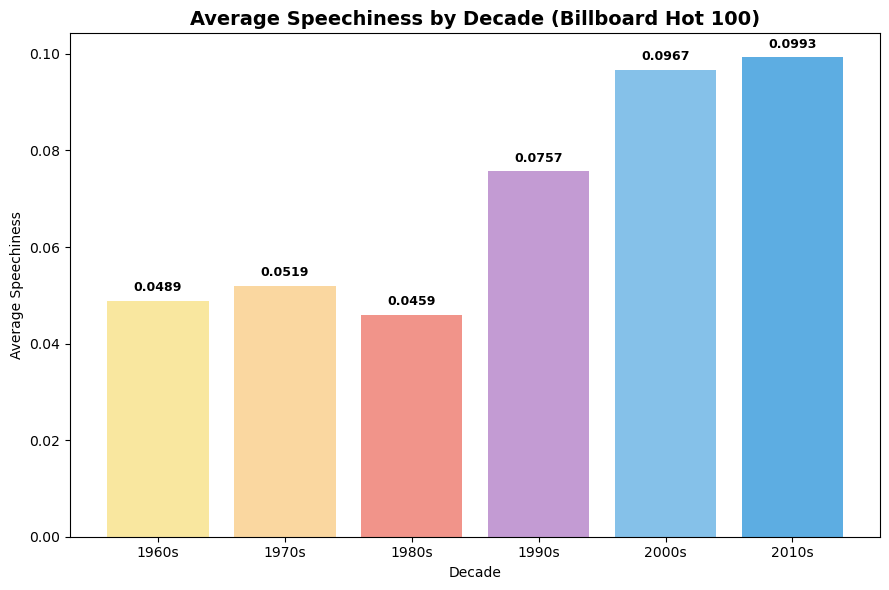

[SAVED] rq3_speechiness_decade.png

1960s avg: 0.0489, 2010s avg: 0.0993, growth: 103.1%


In [18]:
decade_colors = {
    '1960s': '#F9E79F', '1970s': '#FAD7A0', '1980s': '#F1948A',
    '1990s': '#C39BD3', '2000s': '#85C1E9', '2010s': '#5DADE2',
}
fig, ax = plt.subplots(figsize=(9, 6))
colors = [decade_colors[d] for d in speechiness_decade['decade']]
bars = ax.bar(speechiness_decade['decade'], speechiness_decade['avg_speechiness'], color=colors)
for bar, val in zip(bars, speechiness_decade['avg_speechiness']):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.002, f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Average Speechiness by Decade (Billboard Hot 100)', fontsize=14, fontweight='bold')
ax.set_xlabel('Decade'); ax.set_ylabel('Average Speechiness')
plt.tight_layout()
plt.savefig('../Data/rq3_speechiness_decade.png', dpi=120)
plt.show()
print('[SAVED] rq3_speechiness_decade.png')

y1960s = speechiness_decade.loc[speechiness_decade['decade']=='1960s','avg_speechiness'].values[0]
y2010s = speechiness_decade.loc[speechiness_decade['decade']=='2010s','avg_speechiness'].values[0]
growth = round((y2010s - y1960s) / y1960s * 100, 1)
print(f"\n1960s avg: {y1960s}, 2010s avg: {y2010s}, growth: {growth}%")

### Step 18 — 依類型比較（用 D3 的 genre 子集，跟 RQ1 同一個覆蓋率限制）

**⚠️ 沿用 RQ1 已經查證過的限制**：`genre` 只在 D3 有配對的子集才有（14-19% 覆蓋率，且各年代不均），這裡的類型別 speechiness 比較繼承同樣的限制，不是新問題，但要記得提醒讀者。

In [19]:
genre_speech = (
    analysis_base[analysis_base['genre'].notna()]
    .groupby('genre')['speechiness'].mean().round(4)
    .sort_values(ascending=False)
    .reset_index(name='avg_speechiness')
)
genre_speech['n'] = analysis_base[analysis_base['genre'].notna()].groupby('genre').size().reindex(genre_speech['genre']).values
print(genre_speech.to_string(index=False))

  genre  avg_speechiness     n
hip hop           0.2325   895
 reggae           0.1402   159
    pop           0.0690 27700
   rock           0.0480  7544
  blues           0.0474  1644
   jazz           0.0461  1115
country           0.0371  5323


### Step 19 — 類型別 Speechiness 長條圖（Hip-Hop 特別標色）

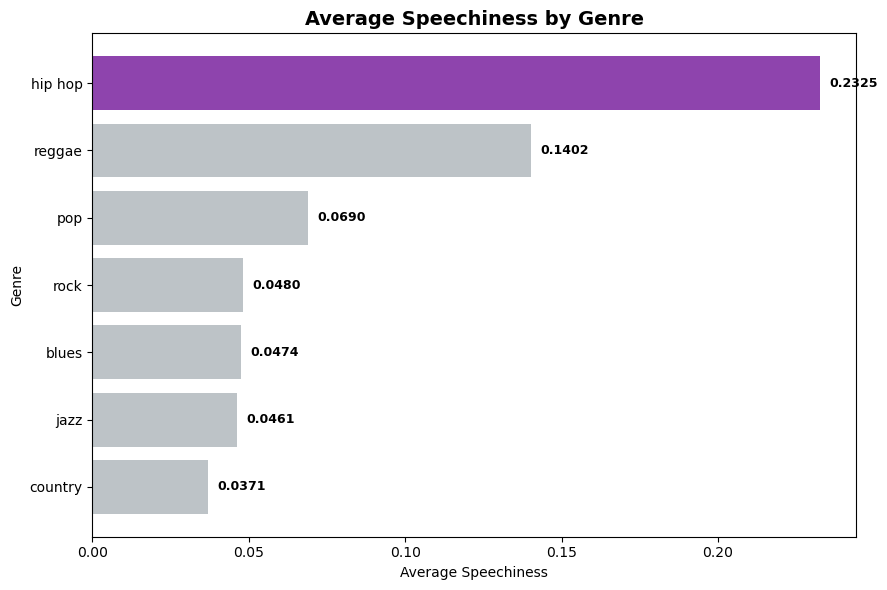

[SAVED] rq3_speechiness_genre.png


In [20]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#8E44AD' if g == 'hip hop' else '#BDC3C7' for g in genre_speech['genre']]
bars = ax.barh(genre_speech['genre'], genre_speech['avg_speechiness'], color=colors)
for bar, val in zip(bars, genre_speech['avg_speechiness']):
    ax.text(val+0.003, bar.get_y()+bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
ax.invert_yaxis()
ax.set_title('Average Speechiness by Genre', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Speechiness'); ax.set_ylabel('Genre')
plt.tight_layout()
plt.savefig('../Data/rq3_speechiness_genre.png', dpi=120)
plt.show()
print('[SAVED] rq3_speechiness_genre.png')

### Step 20 — Hip-Hop vs 其他類型，依年代比較

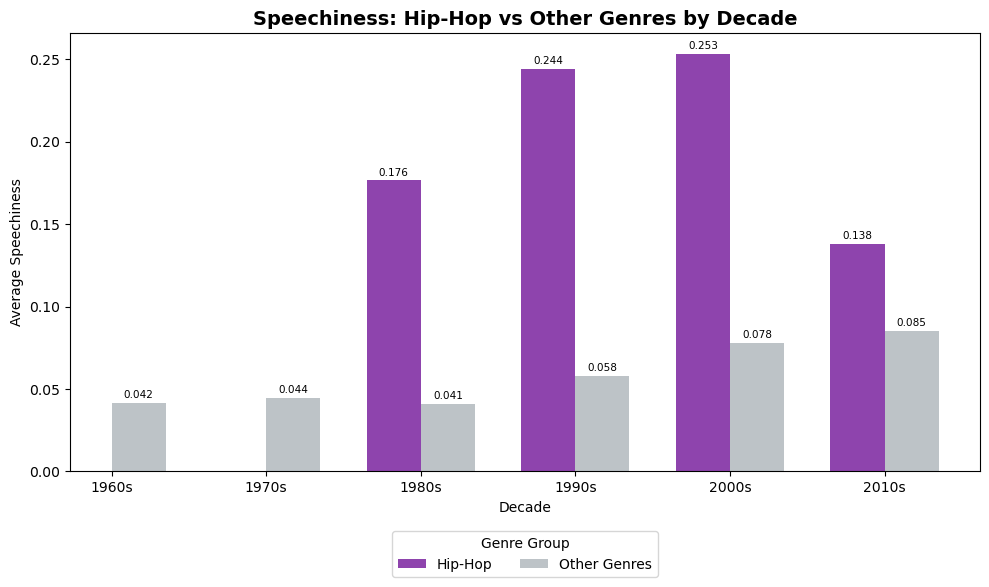

[SAVED] rq3_hiphop_vs_other.png

Hip-Hop average: 0.2325
Other Genres average: 0.0603
Ratio: 3.86x


In [21]:
hh = analysis_base[analysis_base['genre'].notna()].copy()
hh['is_hiphop'] = hh['genre'].apply(lambda g: 'Hip-Hop' if g == 'hip hop' else 'Other Genres')
hh_decade = hh.groupby(['decade', 'is_hiphop'])['speechiness'].mean().round(4).reset_index()

pivot_hh = hh_decade.pivot(index='decade', columns='is_hiphop', values='speechiness').reindex(decade_order)

fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(pivot_hh.index))
width = 0.35
ax.bar([i - width/2 for i in x], pivot_hh['Hip-Hop'], width, label='Hip-Hop', color='#8E44AD')
ax.bar([i + width/2 for i in x], pivot_hh['Other Genres'], width, label='Other Genres', color='#BDC3C7')
for i, (hv, ov) in enumerate(zip(pivot_hh['Hip-Hop'], pivot_hh['Other Genres'])):
    if pd.notna(hv):
        ax.text(i - width/2, hv + 0.003, f'{hv:.3f}', ha='center', fontsize=7.5)
    if pd.notna(ov):
        ax.text(i + width/2, ov + 0.003, f'{ov:.3f}', ha='center', fontsize=7.5)
ax.set_xticks(list(x)); ax.set_xticklabels(pivot_hh.index)
ax.set_title('Speechiness: Hip-Hop vs Other Genres by Decade', fontsize=14, fontweight='bold')
ax.set_xlabel('Decade'); ax.set_ylabel('Average Speechiness')
ax.legend(title='Genre Group', loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2)
plt.tight_layout()
plt.savefig('../Data/rq3_hiphop_vs_other.png', dpi=120)
plt.show()
print('[SAVED] rq3_hiphop_vs_other.png')

hh_avg = hh.loc[hh['is_hiphop']=='Hip-Hop', 'speechiness'].mean()
other_avg = hh.loc[hh['is_hiphop']=='Other Genres', 'speechiness'].mean()
print(f"\nHip-Hop average: {hh_avg:.4f}")
print(f"Other Genres average: {other_avg:.4f}")
print(f"Ratio: {round(hh_avg/other_avg, 2)}x")

### Step 21 — RQ3 收尾觀察（用真的 R 重新驗證，抓到一個 R 報告本身的統計方法錯誤）

**Speechiness 成長、Hip-Hop 平均都對上 R 原文**：1960s 0.0489 → 2010s 0.0993（+103.1%），Hip-Hop 平均 0.2325，兩者跟 Step 17/Step 20 印出的數字逐位吻合。

**⚠️ 但「其他類型平均 0.0646、差距 4.8 倍」這個 R 原文數字，用 `Rscript.exe` 重新驗證後發現是統計方法用錯，不是我這邊算錯**：R 原本這個數字是「先算 6 個類型各自的平均值，再把這 6 個數字簡單平均一次」（mean of means），不是「每一筆歌都算進去的加權平均」（grand mean）。問題在於 reggae 只有 159 筆卻跟 pop 的 27,700 筆用同樣的權重去平均，把數字往上拉高。

**正確的 grand mean（每筆歌都算進去，不是先按類型平均一次）**：Other Genres 平均是 **0.0603**，Hip-Hop 對比倍數是 **3.86 倍**，不是 4.8 倍——這份 notebook 的 Step 20 算出來的數字就是這個正確版本。

**Limitations（跟 R 原文一致，加上 RQ1 這次額外查到的細節）**：
- D3 genre 子集只覆蓋 14-19%（依年代不同，RQ1 已查證），Hip-Hop vs 其他類型的比較建立在這個子集上，不是全體樣本
- 分類重疊：帶饒舌元素的 Pop 曲可能沒被標成 Hip-Hop，可能低估 Hip-Hop 真實影響力——這也呼應 RQ1 觀察到「Hip-Hop 在 genre 分布只有 1990s 有 7.6% 峰值」這個看起來偏低的數字
- Speechiness 本身（來自 D2）覆蓋率是 100%，不受這個限制影響，是比 genre 分類更客觀、更全面的指標——這正是 R 原文選擇用 speechiness 當 Hip-Hop 影響力補充驗證指標的原因